In [1]:
import parse_data as p_d
import descriptive as de
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import parse_data as p_d
import machine as ml
import matplotlib.pyplot as plt

%run classical.ipynb

df = p_d.df

Interaction term: absences:grade_group[T.Low]
  beta = 0.178
  p    = 0.0000
studytime  n   mean(G3)   sd(G3)
        1 105    10.048     4.956
        2 198    10.172     4.218
        3  65    11.400     4.640
        4  27    11.259     5.281

One-way ANOVA (studytime -> G3)
  F(3, 391) = 1.728,  p = 0.1607


I examine factors related to students' final math grades (G3). I focus on two main results:

1. The relationship between the first-period grade (G1) and the final grade (G3).
2. How the relationship between absences and final grades differs between low-perfoming students and high-performing students.

G1–G3: r = 0.801, p = 0.0000


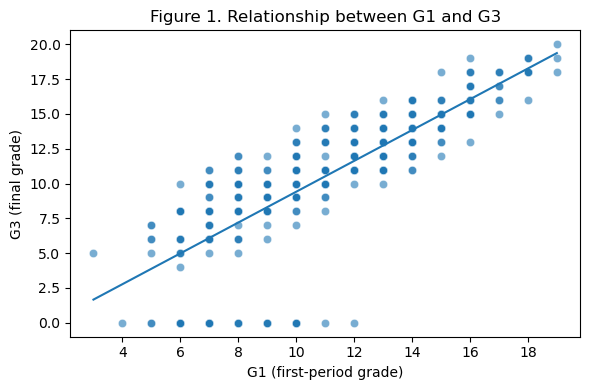

In [2]:
x = df['G1']
y = df['G3']

slope, intercept, r, p, _ = stats.linregress(x, y)
print(f"G1–G3: r = {r:.3f}, p = {p:.4f}")

xline = np.linspace(x.min(), x.max(), 100)
yline = slope * xline + intercept

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, alpha=0.6, edgecolor='white', linewidth=0.5)
ax.plot(xline, yline)

ax.set_xlabel('G1 (first-period grade)')
ax.set_ylabel('G3 (final grade)')
ax.set_title('Figure 1. Relationship between G1 and G3')

plt.tight_layout()
plt.show()

## Result 1: The relationship between the first-period grade (G1) and the final grade (G3)

Figure 1 shows the relation between the first period grade (G1) and the final grade (G3).
A simple linear regression analysis showed a very strong positive correlation between G1 and G3 (r = 0.801, p = 0.0000).
This result means that students who did well at the beginning of the course tended to get higher final grades in the end.

Low group: r = 0.396, p = 0.0000
High group: r = -0.102, p = 0.0979


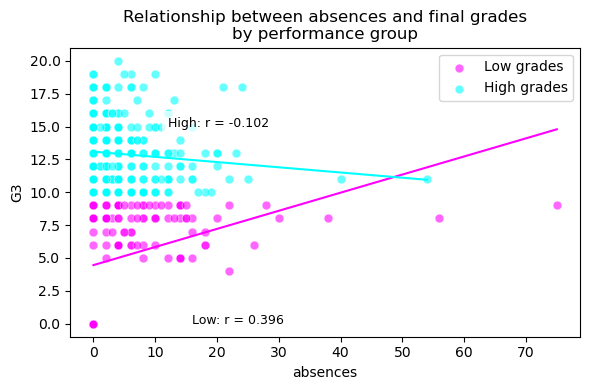

In [3]:
df2 = add_grade_group(df, threshold=10)
fit_interaction_model(df, threshold=10)
fig, ax = plt.subplots(figsize=(6, 4))
colors = {'Low': 'magenta', 'High': 'cyan'}

for grp in ['Low', 'High']:
    sub = df2[df2['grade_group'] == grp]
    ax.scatter(sub['absences'], sub['G3'], alpha=0.6, label=f'{grp} grades',
               edgecolor='white', linewidth=0.5, s=40, color=colors[grp])
    slope, intercept, r, p, _ = stats.linregress(sub['absences'], sub['G3'])
    print(f'{grp} group: r = {r:.3f}, p = {p:.4f}')
    xline = np.linspace(sub['absences'].min(), sub['absences'].max(), 50)
    yline = slope * xline + intercept
    ax.plot(xline, yline, color=colors[grp])
    xpos = sub['absences'].quantile(0.9)
    ypos = sub['G3'].quantile(0.1) if grp == 'Low' else sub['G3'].quantile(0.8)
    ax.text(xpos, ypos, f'{grp}: r = {r:.3f}', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('absences')
ax.set_ylabel('G3')
ax.set_title('Relationship between absences and final grades\nby performance group')
ax.legend()
plt.tight_layout()
plt.show()

## Result 2: Interaction between absences and performance group

Figure 2 shows the relation between absences and the final grade (G3) for low performing students and high performing students separately.
In the low performing group, the number of absences is moderately and positively correlated with G3 (r = 0.396, p < .001), while in the high performing group this correlation is weakly negative and does not reach the significant level (r = -0.102, p = .098).

To examine if the effect of absences to G3 is different between these performance groups, I did a linear regression analysis including an interaction term.

The interaction term between absences and grade_group became statistically significant (β = 0.18, p < .001), which means that the slope of the relation between absences and G3 is different for low and high performing students.
Taken together, these results indicate that the relation between attendance and achievement is not same for all students: in the low performing group, students who have more absences tend to get a little bit higher final grades.

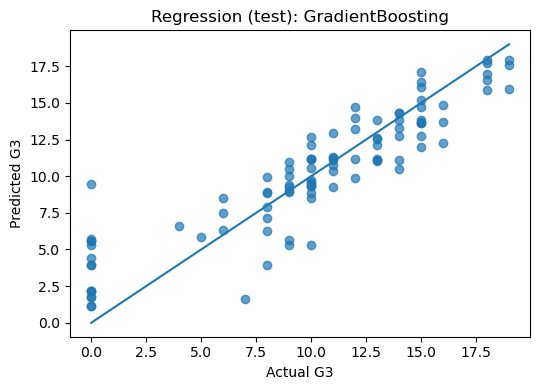

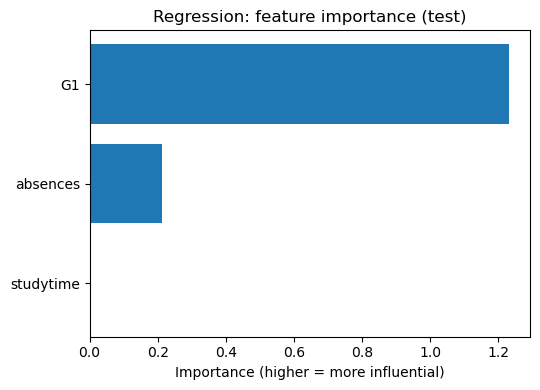

In [4]:
df = p_d.df

results_df, best_name, best_model, split, y_pred, importance = ml.fit_and_evaluate_regression(df, random_state=0)
X_train, X_test, y_train, y_test = split

ml.plot_pred_vs_actual(y_test, y_pred, title=f"Regression (test): {best_name}")
plt.show()

ml.plot_feature_importance(importance, title="Regression: feature importance (test)")
plt.show()